# 03 – Evaluation: Two-Stage U-Net vs Baselines

**CSE445 – Road Surface Crack Detection & Segmentation**

This notebook evaluates models on the **held-out Dashcam/Drone test set** (`test.csv`):
1. Loads the Fine-Tuned Stage 2 model (`crack_stage2_unet_finetuned`)
2. (Optional) Loads Stage 1 baseline for direct comparison
3. Evaluates IoU, Dice, Precision, Recall, Pixel Accuracy across probability thresholds (0.2 – 0.5)
4. Generates visual comparisons & failure case analysis.

In [1]:
import sys, os
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
try:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO = '/content/drive/MyDrive/Road_Damage_Project'
    os.environ['RUN_ENV'] = 'colab'
except ImportError:
    REPO = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    os.environ['RUN_ENV'] = 'local'

if REPO not in sys.path:
    sys.path.insert(0, REPO)
print('Repo root:', REPO)

Repo root: d:\Road_Damage_Project


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

import config
from support.shared.dataset import SegmentationDataset
from support.shared.transforms import get_val_transforms
from support.shared.unet import UNet
from support.shared.metrics import compute_all_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = False
    torch.cuda.empty_cache()
print('Device:', device)

d:\anaconda3\envs\Thesis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 1. Load Checkpoint (Stage 2 Fine-Tuned Model)

In [3]:
# Search for best checkpoint
candidate_ckpts = [
    config.EXP_DIR / 'crack_stage2_unet_finetuned' / 'best_model.pth',
    config.EXP_DIR / 'crack_stage1_unet' / 'best_model.pth',
    config.EXP_DIR / 'crack_unet_run1' / 'best_model.pth',
]
ckpt_path = None
for c in candidate_ckpts:
    if c.exists():
        ckpt_path = c
        break

if ckpt_path is None:
    raise FileNotFoundError('No checkpoint found! Train a model first.')

print('Loading checkpoint from:', ckpt_path)
model = UNet(in_channels=3, out_channels=1, base_features=32)
state = torch.load(ckpt_path, map_location=device)
if isinstance(state, dict) and 'model_state_dict' in state:
    state = state['model_state_dict']
model.load_state_dict(state)
model = model.to(device)
model.eval()
print(f'Model loaded successfully! Parameters: {model.count_parameters():,}')

Loading checkpoint from: D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\best_model.pth
Model loaded successfully! Parameters: 7,849,601


## 2. Load Held-Out Test DataLoader

In [4]:
test_csv = config.CRACK_SPLIT_DIR / 'test.csv'
if not test_csv.exists():
    test_csv = config.CRACK_SPLIT_DIR / 'dashcam_test.csv'

test_ds = SegmentationDataset(test_csv, transform=get_val_transforms((config.IMG_HEIGHT, config.IMG_WIDTH)))
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)
print(f'Test Dataset: {len(test_ds)} samples ({len(test_loader)} batches)')

Test Dataset: 426 samples (27 batches)


## 3. Quantitative Evaluation Across Multiple Thresholds

Sweeping probability thresholds on test set...

  THRESHOLD TUNING EVALUATION RESULTS
 threshold      iou     dice  precision   recall  pixel_acc
      0.15 0.202326 0.300296   0.300779 0.397337   0.994620
      0.20 0.202349 0.300091   0.309155 0.389779   0.994737
      0.25 0.202129 0.299437   0.311750 0.383726   0.994828
      0.30 0.202134 0.299219   0.314084 0.378520   0.994906
      0.35 0.201904 0.298598   0.315983 0.373590   0.994971
      0.40 0.201747 0.298274   0.319615 0.369294   0.995029
      0.45 0.201824 0.298268   0.324742 0.365617   0.995086
      0.50 0.201846 0.298146   0.329817 0.362021   0.995141
Optimal Threshold: 0.20 -> Best Test IoU: 0.2023 | Dice: 0.3001


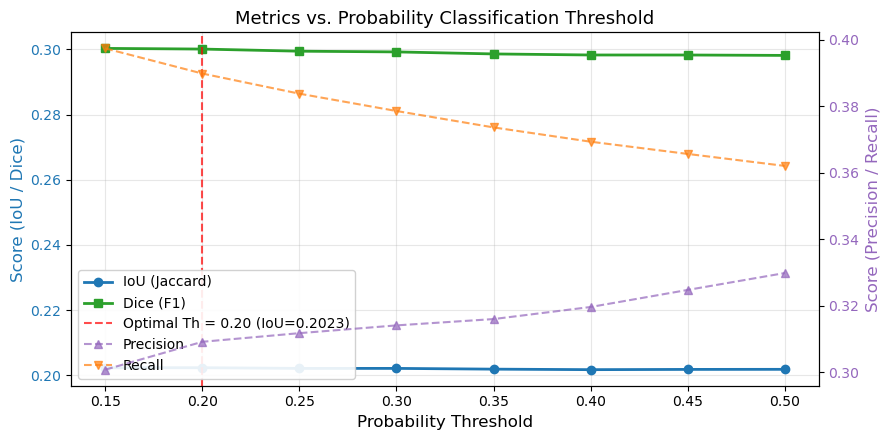

In [5]:
# Threshold Tuning Sweep across Held-Out Test Set
torch.cuda.empty_cache()
thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
results = []
n_batches = len(test_loader)

print("Sweeping probability thresholds on test set...")
for th in thresholds:
    totals = {"iou": 0.0, "dice": 0.0, "pixel_acc": 0.0, "precision": 0.0, "recall": 0.0}
    
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            m = compute_all_metrics(preds, masks, threshold=th)
            for k in totals:
                totals[k] += m[k]
                
    avg_m = {k: v / n_batches for k, v in totals.items()}
    avg_m["threshold"] = th
    results.append(avg_m)

df_res = pd.DataFrame(results)[["threshold", "iou", "dice", "precision", "recall", "pixel_acc"]]
best_row = df_res.loc[df_res["iou"].idxmax()]
best_th = best_row["threshold"]

print("\n" + "=" * 65)
print("  THRESHOLD TUNING EVALUATION RESULTS")
print("=" * 65)
print(df_res.to_string(index=False))
print("=" * 65)
print(f"Optimal Threshold: {best_th:.2f} -> Best Test IoU: {best_row['iou']:.4f} | Dice: {best_row['dice']:.4f}")

# Plot Threshold Response Curves
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(df_res["threshold"], df_res["iou"], "o-", color="tab:blue", lw=2, label="IoU (Jaccard)")
ax1.plot(df_res["threshold"], df_res["dice"], "s-", color="tab:green", lw=2, label="Dice (F1)")
ax1.axvline(best_th, color="red", linestyle="--", alpha=0.7, label=f"Optimal Th = {best_th:.2f} (IoU={best_row['iou']:.4f})")
ax1.set_xlabel("Probability Threshold", fontsize=12)
ax1.set_ylabel("Score (IoU / Dice)", fontsize=12, color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_res["threshold"], df_res["precision"], "^--", color="tab:purple", alpha=0.7, label="Precision")
ax2.plot(df_res["threshold"], df_res["recall"], "v--", color="tab:orange", alpha=0.7, label="Recall")
ax2.set_ylabel("Score (Precision / Recall)", fontsize=12, color="tab:purple")
ax2.tick_params(axis="y", labelcolor="tab:purple")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", framealpha=0.9)
plt.title("Metrics vs. Probability Classification Threshold", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Visualise Predictions vs Ground Truth

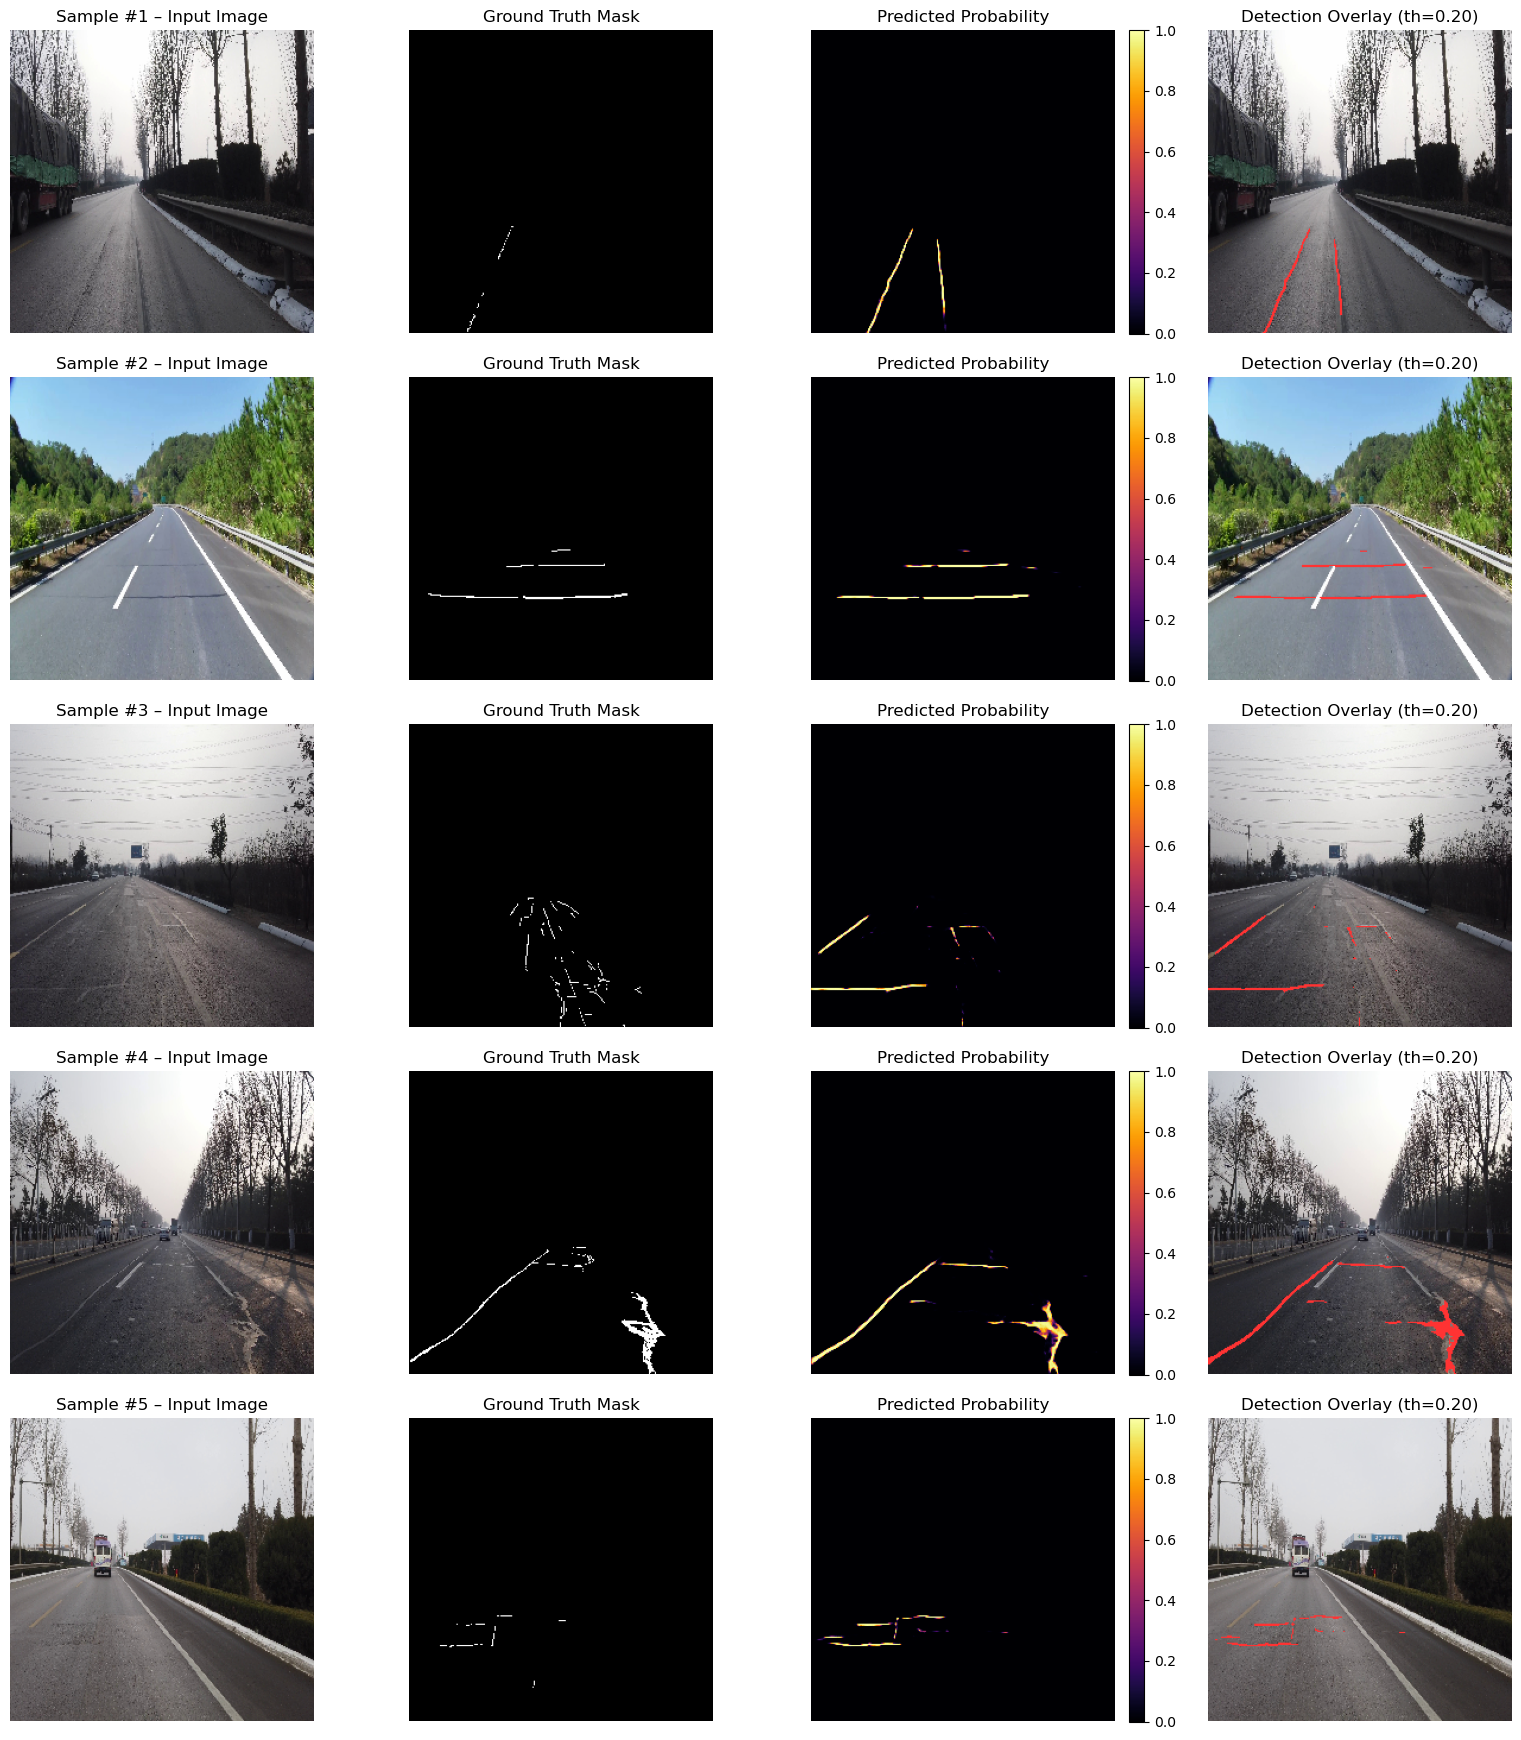

In [6]:
# Pick sample test images and visualise predictions using optimal threshold
n_samples = 5
eval_th = best_th if "best_th" in locals() else 0.35
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 3.5 * n_samples))

inv_mean = [-m/s for m, s in zip(config.AUG["mean"], config.AUG["std"])]
inv_std  = [1.0/s for s in config.AUG["std"]]

for i in range(n_samples):
    img_t, mask_t = test_ds[i * (len(test_ds) // n_samples)]
    with torch.no_grad():
        pred_t = model(img_t.unsqueeze(0).to(device)).squeeze().cpu().numpy()
    
    # Denormalize image for plotting
    img_np = img_t.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array(config.AUG["std"]) + np.array(config.AUG["mean"])
    img_np = np.clip(img_np, 0, 1)
    
    gt_np = mask_t.squeeze().cpu().numpy()
    pred_bin = (pred_t > eval_th).astype(np.float32)
    
    # 1. Original Image
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Sample #{i+1} – Input Image")
    axes[i, 0].axis("off")
    
    # 2. Ground Truth Mask
    axes[i, 1].imshow(gt_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")
    
    # 3. Probability Heatmap
    im = axes[i, 2].imshow(pred_t, cmap="inferno", vmin=0, vmax=1)
    axes[i, 2].set_title("Predicted Probability")
    axes[i, 2].axis("off")
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)
    
    # 4. Binary Overlay
    overlay = img_np.copy()
    overlay[pred_bin > 0] = [1.0, 0.2, 0.2]  # Red overlay for detected crack
    axes[i, 3].imshow(overlay)
    axes[i, 3].set_title(f"Detection Overlay (th={eval_th:.2f})")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()
